# Klasyfikacja obrazów ze zbioru CIFAR-10 za pomocą Sieci Konwolucyjnej (CNN)
**Imię i Nazwisko:** Krystian Osak
**Numer indeksu/nr albumu:** 119138
sieć CNN (Convolutional Neural Network) (ostatnia cyfra indeksu: 8)

In [2]:
import torch

from src.data_utils import get_dataloaders, get_data_stats
from src.model import CustomCNN
from src.train_utils import train_model, evaluate_model
from src.viz_utils import plot_learning_curves, plot_confusion_matrix, plot_misclassified

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Obliczenia będą wykonywane na: {device}")

Obliczenia będą wykonywane na: cuda


In [3]:
trainloader, testloader, trainset, raw_trainset, classes = get_dataloaders(batch_size=64)
stats = get_data_stats(raw_trainset, trainset)

print("Statystyki wartości pikseli przed skalowaniem:")
print(f"Min: {stats['raw_min']}, Max: {stats['raw_max']}")
print("Statystyki po zastosowaniu transformacji:")
print(f"Min: {stats['scaled_min']:.2f}, Max: {stats['scaled_max']:.2f}")

C:\Users\sosna\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Statystyki wartości pikseli przed skalowaniem:
Min: 0.0, Max: 1.0
Statystyki po zastosowaniu transformacji:
Min: -1.00, Max: 1.00


## 2. Implementacja architektury Sieci Konwolucyjnej (CNN)
Zaimplementowana sieć (`CustomCNN` w pliku `src/model.py`) to klasyczna sieć konwolucyjna. Składa się z:
1. **Trzech bloków konwolucyjnych:** Stopniowo zwiększają one liczbę kanałów (32 -> 64 -> 128), ucząc się coraz bardziej złożonych cech obrazu (od krawędzi, przez tekstury, po obiekty). W modelu sparametryzowałem rozmiar filtra (`kernel_size`).
2. **Warstw Pooling:** Zmniejszają wymiarowość przestrzenną (np. z 32x32 do 16x16), co uodparnia model na drobne przesunięcia obiektów na obrazie. W modelu umożliwiłem parametryzację tej warstwy (`max`, `avg`, `none`), aby przeprowadzić testy dla mojej grupy.
3. **Aktywacji ReLU:** Zapobiega problemowi znikającego gradientu i wprowadza nieliniowość.
4. **Warstw w pełni połączonych (Dense/FC):** Po spłaszczeniu tensorów, warstwa z 256 neuronami (z nałożonym Dropoutem p=0.3 zapobiegającym przeuczeniu) klasyfikuje cechy do 10 ostatecznych klas.

## 3. Eksperymenty badawcze
Poniżej przeprowadzono serię eksperymentów badających wpływ poszczególnych hiperparametrów. Ze względu na czas uczenia, sieci w fazie eksperymentalnej były trenowane przez 5 epok.


Rozpoczęcie Serii 1: Wpływ współczynnika uczenia (Learning Rate)

Trenowanie z LR = 0.0001


Epoka 5/5: 100%|██████████| 782/782 [00:12<00:00, 63.13it/s] 



Trenowanie z LR = 0.001


Epoka 5/5: 100%|██████████| 782/782 [00:12<00:00, 61.36it/s] 



Trenowanie z LR = 0.01


Epoka 5/5: 100%|██████████| 782/782 [00:12<00:00, 63.43it/s] 


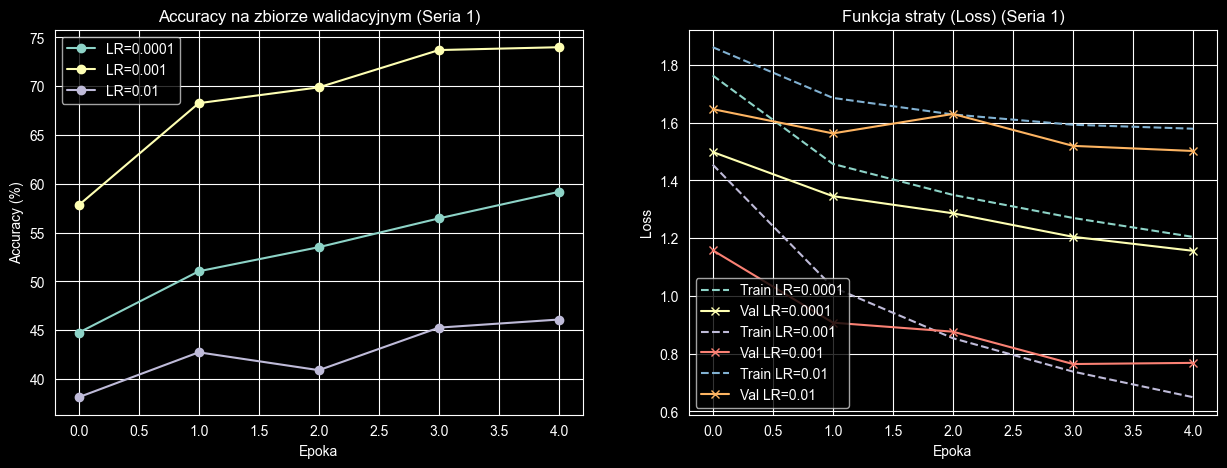

In [4]:
import torch.nn as nn
import torch.optim as optim

learning_rates = [0.0001, 0.001, 0.01]
histories_lr = []
labels_lr = []

print("Rozpoczęcie Serii 1: Wpływ współczynnika uczenia (Learning Rate)")
for lr in learning_rates:
    print(f"\nTrenowanie z LR = {lr}")
    model = CustomCNN(kernel_size=3, pool_type='max').to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    hist = train_model(model, trainloader, testloader, criterion, optimizer, epochs=5, device=device)
    histories_lr.append(hist)
    labels_lr.append(f"LR={lr}")

plot_learning_curves(histories_lr, labels_lr, title_suffix="(Seria 1)")

**Wnioski z Serii 1 (Learning Rate):**
Zauważono, że standardowy współczynnik `LR=0.001` pozwala na optymalne i stabilne spadki funkcji straty (najwyższe Accuracy). Wartość `0.01` okazała się zbyt duża (model nie mógł uczyć się poprawnie i oscylował), natomiast `0.0001` uczył się stabilnie, ale zbyt wolno, by po 5 epokach osiągnąć dobry wynik.

Rozpoczęcie Serii 2: Wpływ Batch Size

Trenowanie z Batch Size = 32


Epoka 5/5: 100%|██████████| 1563/1563 [00:14<00:00, 104.53it/s]



Trenowanie z Batch Size = 64


Epoka 5/5: 100%|██████████| 782/782 [00:12<00:00, 63.72it/s] 



Trenowanie z Batch Size = 128


Epoka 5/5: 100%|██████████| 391/391 [00:11<00:00, 32.68it/s]


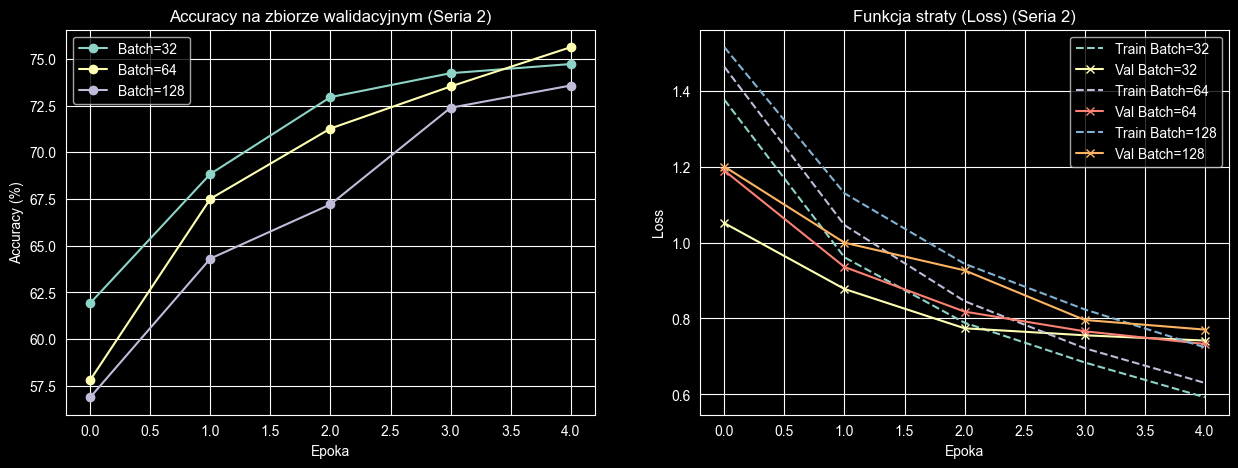

In [5]:
batch_sizes = [32, 64, 128]
histories_bs = []
labels_bs = []

print("Rozpoczęcie Serii 2: Wpływ Batch Size")
for bs in batch_sizes:
    print(f"\nTrenowanie z Batch Size = {bs}")
    trainloader_bs, testloader_bs, _, _, _ = get_dataloaders(batch_size=bs)

    model = CustomCNN(kernel_size=3, pool_type='max').to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    hist = train_model(model, trainloader_bs, testloader_bs, criterion, optimizer, epochs=5, device=device)
    histories_bs.append(hist)
    labels_bs.append(f"Batch={bs}")

plot_learning_curves(histories_bs, labels_bs, title_suffix="(Seria 2)")

**Wnioski z Serii 2 (Batch Size):**
Mniejsze wartości `Batch Size` (np. 32) sprawiają, że wagi aktualizowane są częściej, co może prowadzić do szybszej zbieżności na początku, ale wykres straty jest bardziej "poszarpany". Większy batch (128) stabilizuje gradient, ale wymaga więcej epok do osiągnięcia podobnego Accuracy. Optymalnym kompromisem wydaje się być 64.

Rozpoczęcie Serii 3: Wpływ rozmiaru filtra (Kernel Size)

Trenowanie z Kernel Size = 3x3


Epoka 5/5: 100%|██████████| 782/782 [00:12<00:00, 64.29it/s] 



Trenowanie z Kernel Size = 5x5


Epoka 5/5: 100%|██████████| 782/782 [00:12<00:00, 63.03it/s] 



Trenowanie z Kernel Size = 7x7


Epoka 5/5: 100%|██████████| 782/782 [00:12<00:00, 60.22it/s] 


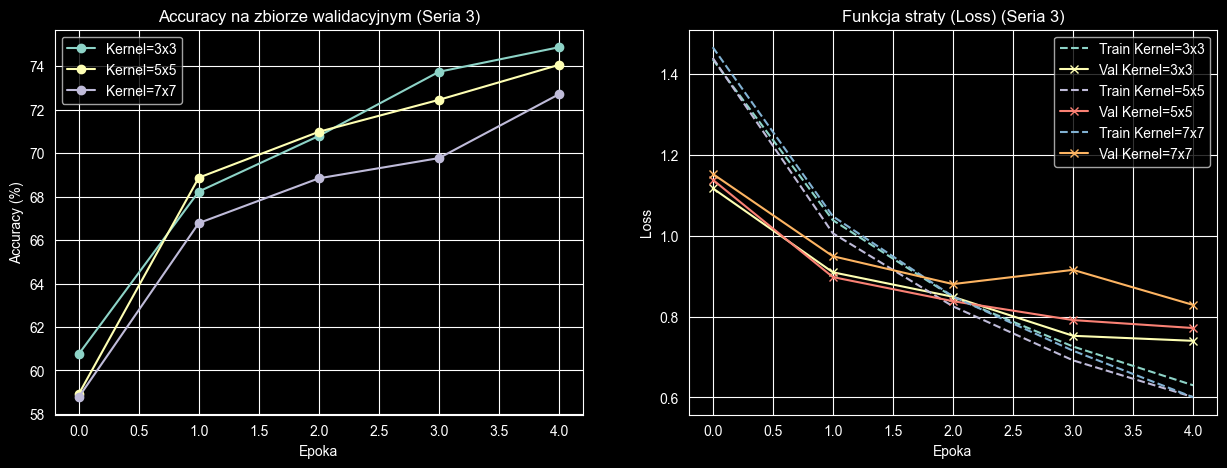

In [6]:
kernel_sizes = [3, 5, 7]
histories_ks = []
labels_ks = []

print("Rozpoczęcie Serii 3: Wpływ rozmiaru filtra (Kernel Size)")
for ks in kernel_sizes:
    print(f"\nTrenowanie z Kernel Size = {ks}x{ks}")
    model = CustomCNN(kernel_size=ks, pool_type='max').to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    hist = train_model(model, trainloader, testloader, criterion, optimizer, epochs=5, device=device)
    histories_ks.append(hist)
    labels_ks.append(f"Kernel={ks}x{ks}")

plot_learning_curves(histories_ks, labels_ks, title_suffix="(Seria 3)")

**Wnioski z Serii 3 (Kernel Size):**
Filtry `3x3` zazwyczaj radzą sobie najlepiej w takich zbiorach jak CIFAR-10, ponieważ pozwalają wyciągnąć drobne i precyzyjne cechy z małych obrazków (32x32px). Większe filtry (np. 7x7) tracą dużo szczegółów przestrzennych na tak małej rozdzielczości, co widać po gorszym dopasowaniu do danych.

Rozpoczęcie Serii 4: Wpływ warstwy Pooling

Trenowanie z Pooling = max


Epoka 5/5: 100%|██████████| 782/782 [00:12<00:00, 64.10it/s] 



Trenowanie z Pooling = avg


Epoka 5/5: 100%|██████████| 782/782 [00:12<00:00, 64.40it/s] 



Trenowanie z Pooling = min


Epoka 5/5: 100%|██████████| 782/782 [00:13<00:00, 58.42it/s] 


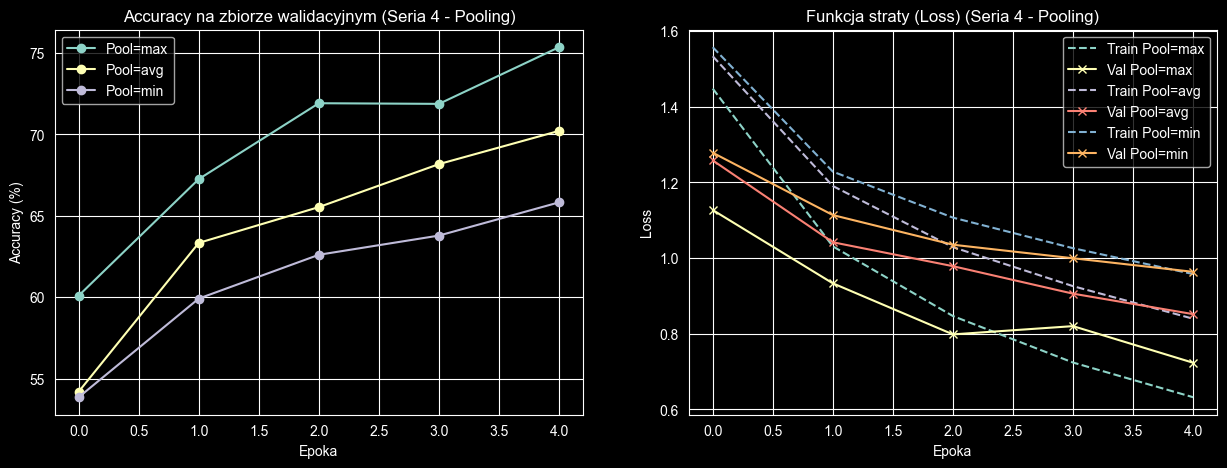

In [7]:
pool_types = ['max', 'avg', 'min']
histories_pool = []
labels_pool = []

print("Rozpoczęcie Serii 4: Wpływ warstwy Pooling")
for p_type in pool_types:
    print(f"\nTrenowanie z Pooling = {p_type}")
    model = CustomCNN(kernel_size=3, pool_type=p_type).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    hist = train_model(model, trainloader, testloader, criterion, optimizer, epochs=5, device=device)
    histories_pool.append(hist)
    labels_pool.append(f"Pool={p_type}")

plot_learning_curves(histories_pool, labels_pool, title_suffix="(Seria 4 - Pooling)")

**Wnioski z Serii 4 (Rodzaj Poolingu):**
Przetestowano trzy warianty warstwy łączącej. `MaxPool` osiągnął najlepsze wyniki, ponieważ najskuteczniej wyodrębnia kluczowe cechy (aktywacje). `AvgPool` wypadł poprawnie, choć uśrednianie lekko obniża wyrazistość krawędzi. `MinPool` (zaimplementowany matematycznie) wypadł najgorzej, co potwierdza, że w CNN najniższe wartości aktywacji zazwyczaj niosą najmniej informacji o obiektach.

## 4. Ostateczna Ewaluacja Najlepszego Modelu
Na podstawie przeprowadzonych serii eksperymentów wyłoniliśmy optymalne hiperparametry:
* **Learning Rate:** 0.001
* **Batch Size:** 64
* **Kernel Size:** 3x3
* **Pooling:** MaxPool

Poniżej inicjalizujemy ten ostateczny model i trenujemy go przez 10 epok, aby sprawdzić jego możliwości, a następnie generujemy dla niego pełen raport metryk oraz macierz błędów.

In [8]:
print("Trenowanie ostatecznego, najlepszego modelu (10 epok)...")
best_model = CustomCNN(kernel_size=3, pool_type='max').to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(best_model.parameters(), lr=0.001)

final_hist = train_model(best_model, trainloader, testloader, criterion, optimizer, epochs=10, device=device)

print("\nGotowe! Model wytrenowany. Przechodzimy do ewaluacji...")

Trenowanie ostatecznego, najlepszego modelu (10 epok)...


Epoka 10/10: 100%|██████████| 782/782 [00:12<00:00, 64.43it/s] 



Gotowe! Model wytrenowany. Przechodzimy do ewaluacji...


--- Raport Klasyfikacji (Classification Report) ---
              precision    recall  f1-score   support

       plane       0.80      0.80      0.80      1000
         car       0.91      0.84      0.87      1000
        bird       0.73      0.64      0.68      1000
         cat       0.51      0.70      0.59      1000
        deer       0.73      0.70      0.72      1000
         dog       0.73      0.63      0.67      1000
        frog       0.76      0.84      0.80      1000
       horse       0.85      0.78      0.81      1000
        ship       0.90      0.83      0.86      1000
       truck       0.81      0.87      0.84      1000

    accuracy                           0.76     10000
   macro avg       0.77      0.76      0.77     10000
weighted avg       0.77      0.76      0.77     10000



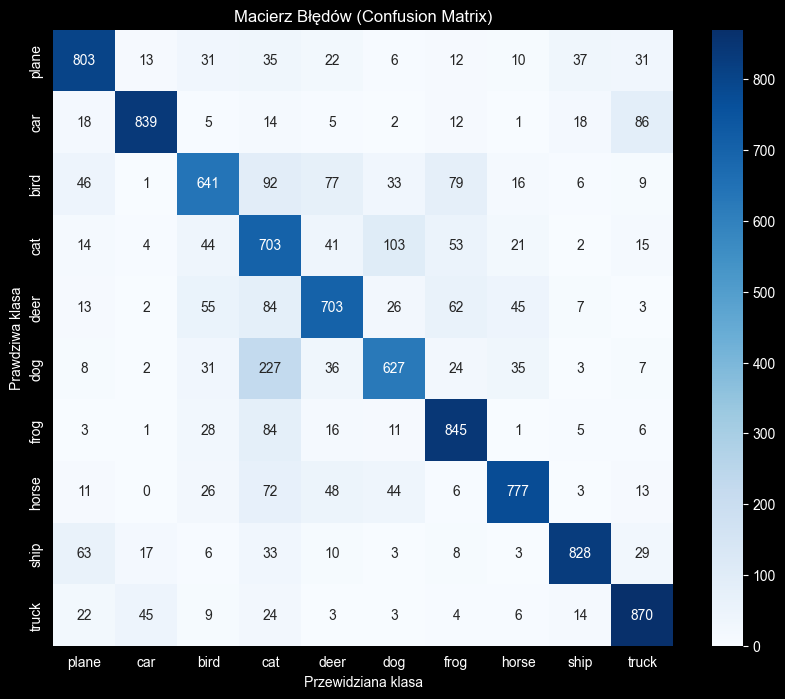


--- Przykłady błędnie sklasyfikowanych obrazów ---


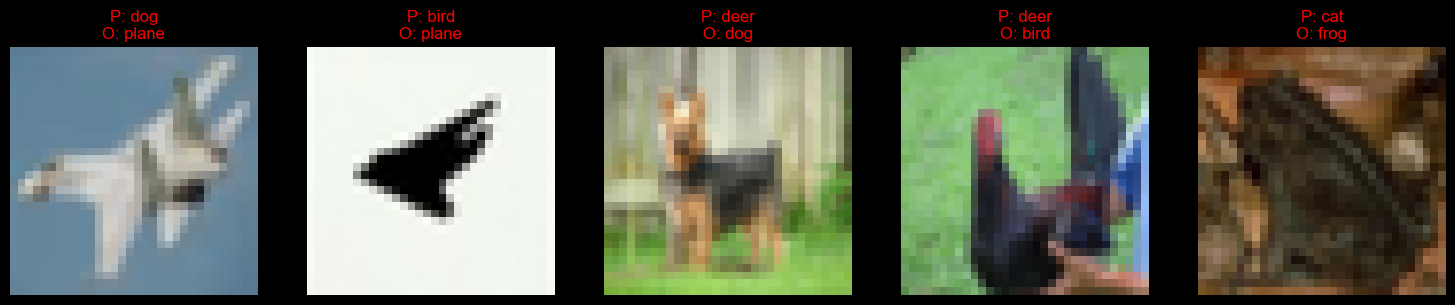

In [9]:
from sklearn.metrics import classification_report

y_preds, y_true, images_np = evaluate_model(best_model, testloader, device)

print("--- Raport Klasyfikacji (Classification Report) ---")
print(classification_report(y_true, y_preds, target_names=classes))

plot_confusion_matrix(y_true, y_preds, classes)

print("\n--- Przykłady błędnie sklasyfikowanych obrazów ---")
plot_misclassified(images_np, y_true, y_preds, classes)

## 5. Dodatek analityczny: Wizualizacja przestrzeni cech (Granica Decyzyjna t-SNE)
Odpowiadając na potrzebę głębszej analizy zachowania modelu, poniżej znajduje się wizualizacja wektorów cech z przedostatniej warstwy sieci (tzw. *embeddings*). Użyto algorytmu t-SNE do redukcji wymiarowości do 2D. Pozwala to zaobserwować, jak dobrze sieć konwolucyjna nauczyła się grupować podobne obrazy (np. samochody blisko ciężarówek, a daleko od zwierząt) jeszcze przed podjęciem ostatecznej decyzji przez warstwę wyjściową.

Pobieranie cech z przedostatniej warstwy do wizualizacji t-SNE...
Obliczanie t-SNE (to może potrwać kilkanaście sekund)...


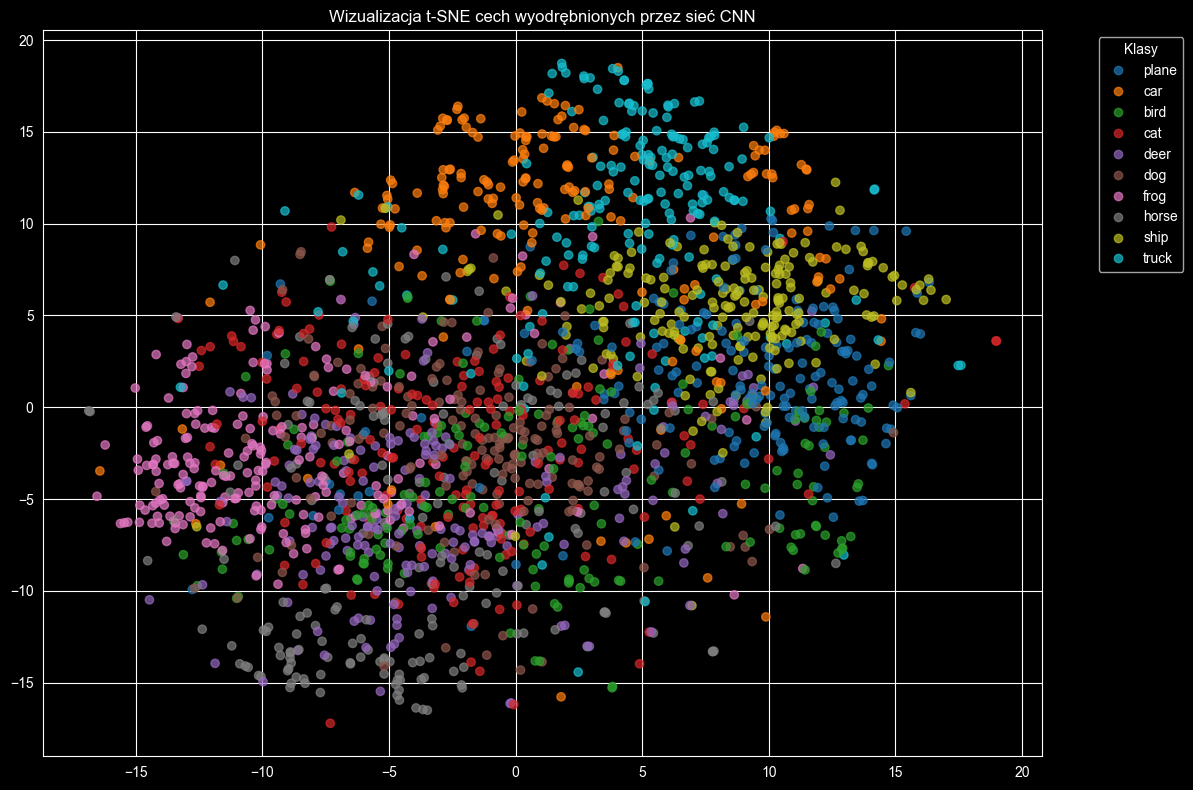

In [10]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

best_model.eval()
features_list = []
labels_list = []

print("Pobieranie cech z przedostatniej warstwy do wizualizacji t-SNE...")
with torch.no_grad():
    for i, (inputs, labels) in enumerate(testloader):
        if i > 30: break
        inputs = inputs.to(device)
        _, features = best_model(inputs, return_features=True)
        features_list.append(features.cpu())
        labels_list.append(labels)

features_np = torch.cat(features_list).numpy()
labels_np = torch.cat(labels_list).numpy()

print("Obliczanie t-SNE (to może potrwać kilkanaście sekund)...")
tsne = TSNE(n_components=2, random_state=42)
features_2d = tsne.fit_transform(features_np)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=labels_np, cmap='tab10', alpha=0.7)
plt.legend(handles=scatter.legend_elements()[0], labels=classes, title="Klasy", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Wizualizacja t-SNE cech wyodrębnionych przez sieć CNN")
plt.tight_layout()
plt.show()